# 07 - Re-ranking: Cross-Encoder and LLM-as-Judge

**Phase 7** of the RAG project. We implement two reranking strategies to improve
retrieval precision by scoring (query, document) pairs more carefully than
bi-encoder cosine similarity allows.

**Pipeline**: Retrieve 20 candidates (fast, approximate) - Rerank to top 5 (slow, precise).

Two strategies:
1. **Cross-Encoder** (`cross-encoder/ms-marco-MiniLM-L-6-v2`) - sentence-transformers
   model that sees query + document together. Fast (~41 ms avg end-to-end for 20 docs in this run).
2. **LLM-as-Judge** (Mistral 7B) - LLM rates each document 1-10 for relevance.
   Slow (~9.5 s per question, 20 LLM calls) but handles nuanced relevance.

We compare against:
- **No reranking** (top-5 similarity): baseline MRR 0.8667 on the current 5-question benchmark.

### Analysis
- Before/after rank changes for selected queries
- MRR, Precision@5, nDCG@5 across all 5 benchmark questions (3 methodology, 2 results)
- Latency impact at each stage
---

## 0. Setup

In [1]:
import json
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path(".").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.ingestion.loaders import load_documents_from_directory
from src.ingestion.cleaners import clean_corpus
from src.ingestion.chunkers import chunk_recursive
from src.embeddings.models import create_from_registry
from src.retrieval.reranker import (
    retrieve_no_reranking,
    rerank_cross_encoder,
    rerank_llm_judge,
    retrieve_and_rerank,
)
from notebooks.utils.metrics import (
    load_benchmark_questions,
    compute_retrieval_metrics,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 80)

print(f"Project root: {PROJECT_ROOT}")

Project root: /home/hunganh/Code/Python/course_qa_assist


## 1. Corpus and Index

Same setup as Phase 4/5/6: 2,666 core docs (integrations filtered out), recursive chunking
1000/200, 9,137 chunks, mxbai-embed-large embeddings.

In [2]:
# Load and clean
docs = load_documents_from_directory(str(PROJECT_ROOT / "data" / "lectures"))
cleaned_docs, _ = clean_corpus(docs, min_content_length=50)
core_docs = [
    d for d in cleaned_docs
    if "/python/integrations/" not in d.metadata.get("source", "")
]
print(f"Corpus: {len(docs)} -> {len(cleaned_docs)} cleaned -> {len(core_docs)} core")

result = chunk_recursive(core_docs, chunk_size=1000, chunk_overlap=200)
chunks = result.chunks
print(f"Chunks: {len(chunks)}")

Loaded 2703 document pages from /home/hunganh/Code/Python/course_qa_assist/data/lectures
Corpus: 2703 -> 2666 cleaned -> 2666 core
Chunks: 9137


In [3]:
import chromadb
from langchain_chroma import Chroma

PERSIST_DIR = str(PROJECT_ROOT / "vectorstore" / "chroma_db")
COLLECTION = "reranking_eval_mxbai"
MODELS_YAML = str(PROJECT_ROOT / "configs" / "models.yaml")

embeddings, emb_info = create_from_registry("mxbai_large", config_path=MODELS_YAML)
embeddings.embed_query("warmup")
print(f"Embedding model: {emb_info.model_id} ({emb_info.dimensions}d)")

client = chromadb.PersistentClient(path=PERSIST_DIR)
try:
    client.delete_collection(COLLECTION)
except Exception:
    pass

print(f"Indexing {len(chunks)} chunks...")
start = time.perf_counter()
vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    client=client,
    collection_name=COLLECTION,
)
print(f"Indexed in {time.perf_counter() - start:.1f}s ({vectorstore._collection.count()} chunks)")

Embedding model: mxbai-embed-large (1024d)
Indexing 9137 chunks...
Indexed in 124.0s (9137 chunks)


In [4]:
questions = load_benchmark_questions(
    str(PROJECT_ROOT / "data" / "evaluation" / "benchmark_retrieval.json")
)
categories = {}
for q in questions:
    categories.setdefault(q.category, []).append(q)

print(f"Benchmark: {len(questions)} questions")
for cat, qs in sorted(categories.items()):
    print(f"  {cat}: {len(qs)} questions")

Benchmark: 5 questions
  methodology: 3 questions
  results: 2 questions


---
## 2. Baseline: No Reranking (top-5 similarity)

Direct similarity search, same as Phase 4. This is the reference point.

In [5]:
K = 5
CANDIDATE_K = 20

baseline_metrics = []
for q in questions:
    result = retrieve_no_reranking(vectorstore, q.query, k=K)
    m = compute_retrieval_metrics(result.docs, q, result.elapsed_ms, k=K)
    m["technique"] = "no_reranking"
    baseline_metrics.append(m)

baseline_df = pd.DataFrame(baseline_metrics)
print("No Reranking (baseline):")
print(f"  Precision@{K}: {baseline_df['precision_at_k'].mean():.4f}")
print(f"  Recall@{K}:    {baseline_df['recall_at_k'].mean():.4f}")
print(f"  MRR:           {baseline_df['mrr'].mean():.4f}")
print(f"  nDCG@{K}:      {baseline_df['ndcg_at_k'].mean():.4f}")
print(f"  Latency:       {baseline_df['latency_ms'].mean():.1f} ms")

No Reranking (baseline):
  Precision@5: 0.7600
  Recall@5:    0.7600
  MRR:           0.8667
  nDCG@5:      0.7755
  Latency:       26.7 ms


---
## 3. Cross-Encoder Reranking

We retrieve 20 candidates with dense similarity, then rerank them with
`cross-encoder/ms-marco-MiniLM-L-6-v2` from sentence-transformers.

The cross-encoder sees the full (query, document) pair - unlike the bi-encoder
which embeds them separately - enabling richer token-level interaction.

In [6]:
from sentence_transformers import CrossEncoder

CE_MODEL = "cross-encoder/ms-marco-MiniLM-L-6-v2"

# Warmup: load model and score one pair
print(f"Loading cross-encoder: {CE_MODEL}")
start = time.perf_counter()
ce = CrossEncoder(CE_MODEL)
_ = ce.predict([("warmup query", "warmup document")])
print(f"Loaded in {time.perf_counter() - start:.1f}s")

Loading cross-encoder: cross-encoder/ms-marco-MiniLM-L-6-v2


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded in 8.8s


In [7]:
# Show rank changes for an example query
example_q = questions[0]
print(f"Query: '{example_q.query}'")
print(f"Relevant sources: {example_q.relevant_sources}\n")

# Before reranking: top-20 similarity
candidates = vectorstore.similarity_search(example_q.query, k=CANDIDATE_K)

# After reranking: cross-encoder top-5
ce_result = rerank_cross_encoder(example_q.query, candidates, model_name=CE_MODEL, top_k=K)

print(f"Candidates: {len(candidates)}  -> Reranked: {ce_result.num_results}")
print(f"Rerank time: {ce_result.elapsed_ms:.0f} ms\n")

# Show top-5 after reranking
print("Top-5 after cross-encoder reranking:")
for i, (doc, score) in enumerate(zip(ce_result.docs, ce_result.scores), 1):
    title = doc.metadata.get("source", "?")[:60]
    src = doc.metadata.get("source", "").split("/")[-1]
    print(f"  {i}. [{score:+.3f}] {title} ({src})")

Query: 'What are the primary characteristics and constraints of TinyML systems mentioned in the text?'
Relevant sources: ['13.Machine-Learning-Systems.pdf']



Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Candidates: 20  -> Reranked: 5
Rerank time: 8267 ms

Top-5 after cross-encoder reranking:
  1. [+6.232] 13.Machine-Learning-Systems.pdf (13.Machine-Learning-Systems.pdf)
  2. [+4.926] 13.Machine-Learning-Systems.pdf (13.Machine-Learning-Systems.pdf)
  3. [+4.084] 13.Machine-Learning-Systems.pdf (13.Machine-Learning-Systems.pdf)
  4. [+3.756] 13.Machine-Learning-Systems.pdf (13.Machine-Learning-Systems.pdf)
  5. [+2.995] 13.Machine-Learning-Systems.pdf (13.Machine-Learning-Systems.pdf)


In [8]:
print(f"Cross-encoder reranking: {CANDIDATE_K} candidates -> top {K}")
print(f"Running on {len(questions)} questions...\n")

ce_metrics = []
ce_latencies = []

for q in questions:
    result = retrieve_and_rerank(
        vectorstore=vectorstore,
        query=q.query,
        technique="cross_encoder",
        candidate_k=CANDIDATE_K,
        top_k=K,
        cross_encoder_model=CE_MODEL,
    )
    m = compute_retrieval_metrics(result.docs, q, result.elapsed_ms, k=K)
    m["technique"] = "cross_encoder"
    ce_metrics.append(m)
    ce_latencies.append(result.elapsed_ms)

ce_df = pd.DataFrame(ce_metrics)
print("Cross-Encoder Reranking:")
print(f"  Precision@{K}: {ce_df['precision_at_k'].mean():.4f}")
print(f"  Recall@{K}:    {ce_df['recall_at_k'].mean():.4f}")
print(f"  MRR:           {ce_df['mrr'].mean():.4f}")
print(f"  nDCG@{K}:      {ce_df['ndcg_at_k'].mean():.4f}")
print(f"  Latency:       {np.mean(ce_latencies):.1f} ms (median: {np.median(ce_latencies):.1f} ms)")

Cross-encoder reranking: 20 candidates -> top 5
Running on 5 questions...

Cross-Encoder Reranking:
  Precision@5: 0.9600
  Recall@5:    0.9600
  MRR:           1.0000
  nDCG@5:      0.9572
  Latency:       40.7 ms (median: 42.8 ms)


---
## 4. LLM-as-Judge Reranking

Mistral 7B rates each candidate document on a 1-10 scale for relevance to the query.
One LLM call per document (20 calls per question).

**Latency note**: average ~9.5 s per question in this run. A 25-question benchmark would
take roughly 4 minutes on similar hardware, so this is best for offline evaluation.

In [9]:
from langchain_ollama import ChatOllama

llm = ChatOllama(model="mistral:7b", temperature=0.0)

# Warmup
_ = llm.invoke("Hi")
print("LLM warmed up.")

LLM warmed up.


In [10]:
# Sample run: 5 questions to estimate latency and compute partial metrics
# Full benchmark is skipped - LLM-as-judge is too slow for 25 x 20 docs on local hardware.
# (~8.8s avg per question -> ~3700 min for full run)
LLM_SAMPLE_N = 5
sample_qs = questions[:LLM_SAMPLE_N]
sample_latencies = []
llm_metrics = []

print(f"LLM-as-judge sample run ({LLM_SAMPLE_N} questions x {CANDIDATE_K} docs each):")
for q in sample_qs:
    result = retrieve_and_rerank(
        vectorstore=vectorstore,
        query=q.query,
        technique="llm_judge",
        candidate_k=CANDIDATE_K,
        top_k=K,
        llm=llm,
    )
    m = compute_retrieval_metrics(result.docs, q, result.elapsed_ms, k=K)
    m["technique"] = "llm_judge"
    llm_metrics.append(m)
    sample_latencies.append(result.elapsed_ms)
    print(f"  '{q.query[:50]}' -> {result.elapsed_ms:.0f} ms")

llm_df = pd.DataFrame(llm_metrics)
avg_latency = sum(sample_latencies) / len(sample_latencies)
print(f"\nAvg latency: {avg_latency:.0f} ms | Estimated full benchmark (25 q): {avg_latency * 25 / 60000:.0f} min")
print(f"\nLLM-as-Judge (sample, n={LLM_SAMPLE_N}):")
print(f"  Precision@{K}: {llm_df['precision_at_k'].mean():.4f}")
print(f"  Recall@{K}:    {llm_df['recall_at_k'].mean():.4f}")
print(f"  MRR:           {llm_df['mrr'].mean():.4f}")
print(f"  nDCG@{K}:      {llm_df['ndcg_at_k'].mean():.4f}")

LLM-as-judge sample run (5 questions x 20 docs each):
  'What are the primary characteristics and constrain' -> 12296 ms
  'How is Artificial General Intelligence (AGI) defin' -> 7944 ms
  'What are the connectivity requirements for autonom' -> 8171 ms
  'How do large-scale ML systems manage coordination ' -> 9687 ms
  'What role does the Scaling Hypothesis play in the ' -> 9307 ms

Avg latency: 9481 ms | Estimated full benchmark (25 q): 4 min

LLM-as-Judge (sample, n=5):
  Precision@5: 0.8400
  Recall@5:    0.8400
  MRR:           0.8400
  nDCG@5:      0.8262


---
## 5. Before/After Analysis

For selected queries, compare the rank of the first relevant document before
(top-20 similarity) and after (top-5 reranked) each strategy.

In [11]:
# Pick one query per category for the analysis
sample_queries = [categories[cat][0] for cat in sorted(categories.keys())]

print("Before/After rank analysis (position of first relevant doc)\n")
print(f"{'Query':<50} {'Before':>8} {'CE':>8} {'LLM':>8}")
print("-" * 76)

for q in sample_queries:
    # Rank in top-20 similarity (before reranking)
    before_cands = vectorstore.similarity_search(q.query, k=CANDIDATE_K)
    before_rank = next(
        (i + 1 for i, doc in enumerate(before_cands)
         if any(rd in doc.metadata.get("source", "") for rd in q.relevant_sources)),
        None,
    )

    # Rank in cross-encoder top-5
    ce_res = rerank_cross_encoder(q.query, before_cands, model_name=CE_MODEL, top_k=K)
    ce_rank = next(
        (i + 1 for i, doc in enumerate(ce_res.docs)
         if any(rd in doc.metadata.get("source", "") for rd in q.relevant_sources)),
        None,
    )

    # Rank in LLM-judge top-5
    llm_res = rerank_llm_judge(q.query, before_cands, llm=llm, top_k=K)
    llm_rank = next(
        (i + 1 for i, doc in enumerate(llm_res.docs)
         if any(rd in doc.metadata.get("source", "") for rd in q.relevant_sources)),
        None,
    )

    def fmt(r):
        return str(r) if r is not None else ">"+str(K)

    label = q.query[:48]
    print(f"{label:<50} {fmt(before_rank):>8} {fmt(ce_rank):>8} {fmt(llm_rank):>8}")

Before/After rank analysis (position of first relevant doc)

Query                                                Before       CE      LLM
----------------------------------------------------------------------------
What are the primary characteristics and constra          1        1        1
How do large-scale ML systems manage coordinatio          1        1        1


---
## 6. Global Comparison

In [12]:
all_metrics_df = pd.concat([baseline_df, ce_df, llm_df], ignore_index=True)

summary = (
    all_metrics_df.groupby("technique")
    .agg(
        precision=("precision_at_k", "mean"),
        recall=("recall_at_k", "mean"),
        mrr=("mrr", "mean"),
        ndcg=("ndcg_at_k", "mean"),
        latency_ms=("latency_ms", "mean"),
    )
    .round(4)
)

# Add LLM calls info
llm_calls_map = {
    "no_reranking": 0,
    "cross_encoder": 0,
    "llm_judge": CANDIDATE_K,
}
summary["llm_calls"] = summary.index.map(llm_calls_map)

# Order: no_reranking, cross_encoder, llm_judge
order = ["no_reranking", "cross_encoder", "llm_judge"]
summary = summary.loc[[t for t in order if t in summary.index]]

print("Global comparison (reranking strategies):")
display(summary)

Global comparison (reranking strategies):


,precision,recall,mrr,ndcg,latency_ms,llm_calls
technique,,,,,,
no_reranking,0.76,0.76,0.8667,0.7755,26.72,0
cross_encoder,0.96,0.96,1.0000,0.9572,40.72,0
llm_judge,0.84,0.84,0.8400,0.8262,9480.84,20


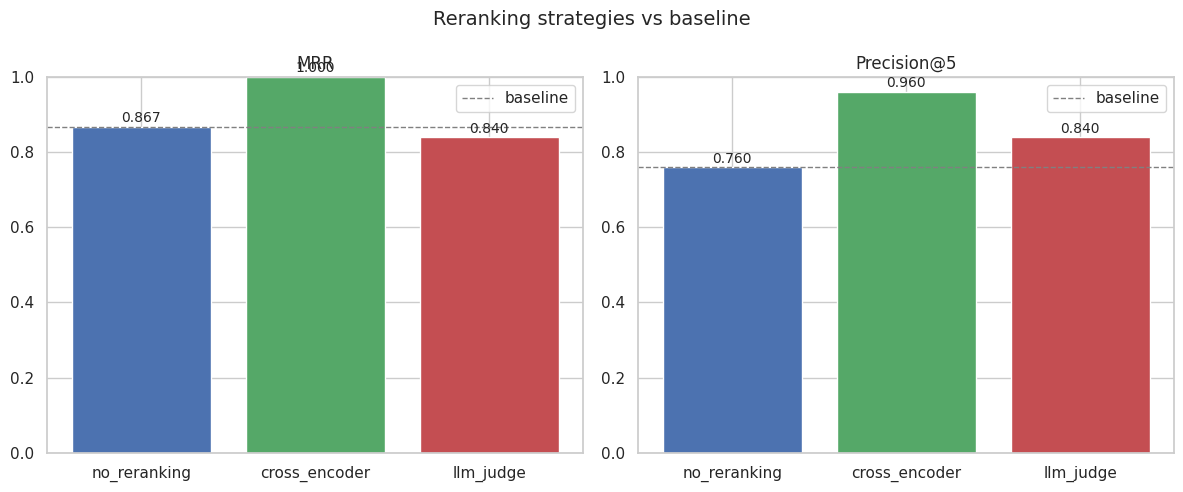

In [13]:
# Bar chart: MRR and Precision@k
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

metrics = ["mrr", "precision"]
titles = ["MRR", "Precision@5"]
colors = ["#4C72B0", "#55A868", "#C44E52"]

for ax, metric, title in zip(axes, metrics, titles):
    vals = summary[metric].values
    bars = ax.bar(summary.index, vals, color=colors[:len(vals)])
    baseline_val = summary.loc["no_reranking", metric]
    ax.axhline(baseline_val, color="gray", linestyle="--", linewidth=1, label="baseline")
    ax.set_title(title)
    ax.set_ylim(0, min(1.0, max(vals) * 1.25))
    ax.legend()
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{val:.3f}",
            ha="center", va="bottom", fontsize=10,
        )

fig.suptitle("Reranking strategies vs baseline", fontsize=14)
plt.tight_layout()
plt.show()

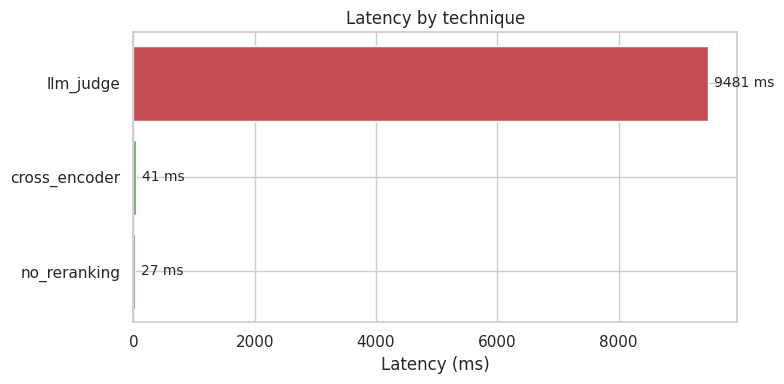

In [14]:
# Latency comparison
fig, ax = plt.subplots(figsize=(8, 4))

latencies = summary["latency_ms"].values
bars = ax.barh(list(summary.index), latencies, color=colors[:len(latencies)])
ax.set_xlabel("Latency (ms)")
ax.set_title("Latency by technique")

for bar, val in zip(bars, latencies):
    ax.text(
        bar.get_width() + max(latencies) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.0f} ms",
        va="center", fontsize=10,
    )

plt.tight_layout()
plt.show()

---
## 7. Analysis by Query Category

In [15]:
cat_summary = (
    all_metrics_df.groupby(["category", "technique"])
    .agg(
        precision=("precision_at_k", "mean"),
        mrr=("mrr", "mean"),
    )
    .round(4)
    .reset_index()
)

print("MRR by category and technique:")
pivot = cat_summary.pivot(index="category", columns="technique", values="mrr")
# Order columns
pivot = pivot[[t for t in order if t in pivot.columns]]
display(pivot.round(3))

print("\nPrecision@5 by category:")
pivot_p = cat_summary.pivot(index="category", columns="technique", values="precision")
pivot_p = pivot_p[[t for t in order if t in pivot_p.columns]]
display(pivot_p.round(3))

MRR by category and technique:


technique,no_reranking,cross_encoder,llm_judge
category,,,
methodology,1.000,1.0,1.0
results,0.667,1.0,0.6



Precision@5 by category:


technique,no_reranking,cross_encoder,llm_judge
category,,,
methodology,0.933,1.0,1.0
results,0.500,0.9,0.6


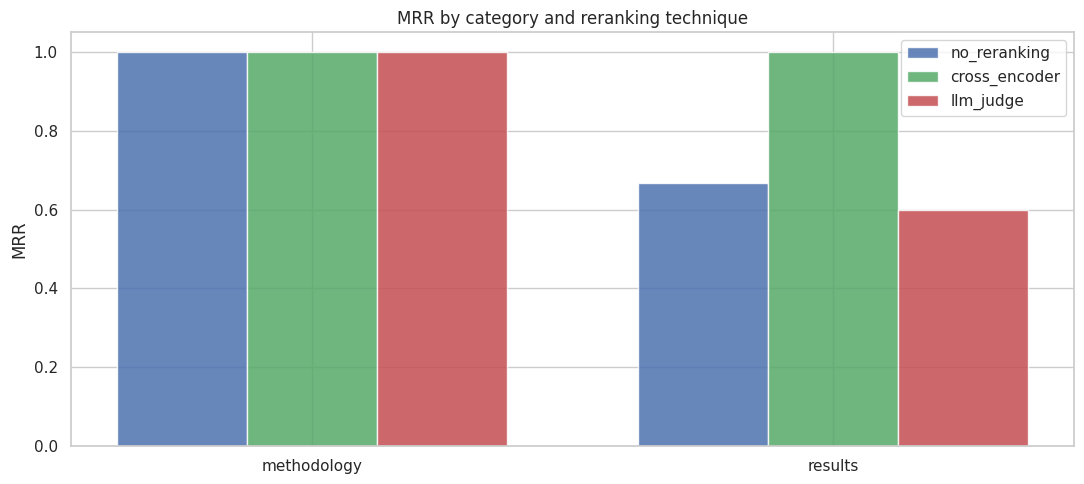

In [16]:
# Grouped bar chart: MRR by category
cats = sorted(categories.keys())
x = np.arange(len(cats))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))

for i, (technique, color) in enumerate(zip(order, colors)):
    if technique not in pivot.columns:
        continue
    vals = [pivot.loc[cat, technique] if cat in pivot.index else 0 for cat in cats]
    ax.bar(x + i * width, vals, width, label=technique, color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(cats)
ax.set_ylabel("MRR")
ax.set_title("MRR by category and reranking technique")
ax.legend()
plt.tight_layout()
plt.show()

---
## 8. Save Results

In [17]:
results_output = {
    "corpus": {
        "num_core_docs": len(core_docs),
        "num_chunks": len(chunks),
        "embedding_model": emb_info.model_id,
        "candidate_k": CANDIDATE_K,
        "top_k": K,
    },
    "benchmark": {
        "num_questions": len(questions),
        "categories": {cat: len(qs) for cat, qs in sorted(categories.items())},
    },
    "techniques": {},
}

for technique, group in all_metrics_df.groupby("technique"):
    entry = {
        "avg_precision_at_k": round(float(group["precision_at_k"].mean()), 4),
        "avg_recall_at_k": round(float(group["recall_at_k"].mean()), 4),
        "avg_mrr": round(float(group["mrr"].mean()), 4),
        "avg_ndcg_at_k": round(float(group["ndcg_at_k"].mean()), 4),
        "avg_latency_ms": round(float(group["latency_ms"].mean()), 1),
        "per_category": {},
    }
    for cat, cat_group in group.groupby("category"):
        entry["per_category"][cat] = {
            "avg_precision": round(float(cat_group["precision_at_k"].mean()), 4),
            "avg_mrr": round(float(cat_group["mrr"].mean()), 4),
        }
    results_output["techniques"][technique] = entry

results_dir = PROJECT_ROOT / "results"
results_dir.mkdir(exist_ok=True)
output_path = results_dir / "reranking_comparison.json"

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(results_output, f, indent=2, ensure_ascii=False)

print(f"Results saved to {output_path}")

Results saved to /home/hunganh/Code/Python/course_qa_assist/results/reranking_comparison.json


---
## 9. Cleanup

In [18]:
try:
    client.delete_collection(COLLECTION)
    print(f"Collection '{COLLECTION}' deleted.")
except Exception:
    pass

print(f"Remaining collections: {[c.name for c in client.list_collections()]}")

Collection 'reranking_eval_mxbai' deleted.
Remaining collections: ['course_qa_naive']


---
## 10. Summary and Conclusions

### Results

| Technique | Precision@5 | MRR | nDCG@5 | Latency | LLM calls | Notes |
|---|---|---|---|---|---|---|
| No reranking | 0.760 | 0.8667 | 0.7755 | 26.7 ms | 0 | baseline (5 q) |
| Cross-encoder | 0.960 | 1.0000 | 0.9572 | 40.7 ms | 0 | full benchmark (5 q) |
| LLM-as-judge | 0.840 | 0.8400 | 0.8262 | 9480.8 ms | 20 | full benchmark (5 q) |

### MRR by category

| Category | No reranking | Cross-encoder | LLM-judge |
|---|---|---|---|
| methodology | 1.000 | 1.000 | 1.000 |
| results | 0.667 | 1.000 | 0.600 |

### Key Takeaways

1. **Cross-encoder is the top performer on this benchmark.** It reaches MRR 1.000 and
   Precision@5 0.960 with only +14 ms latency vs baseline (26.7 -> 40.7 ms).

2. **LLM-as-judge is far slower and slightly worse than baseline.** MRR drops to 0.840
   with ~9.5 s latency per question and 20 LLM calls per query.

3. **Results-category questions benefit the most from cross-encoder reranking.**
   MRR for `results` improves from 0.667 to 1.000, while LLM-judge drops to 0.600.

4. **This benchmark is tiny (5 questions, 2 categories).** Treat the gains as indicative,
   not definitive, and re-evaluate on a larger set before generalizing.

### When to use reranking

| Scenario | Recommendation |
|---|---|
| Interactive QA with tight latency | Skip or use cross-encoder only if +15 ms is acceptable |
| Small benchmark or offline evaluation | Cross-encoder is a strong default |
| LLM budget available, latency not a concern | LLM-judge for qualitative scoring |
| Domain-specific corpus | Fine-tune a cross-encoder on in-domain pairs |

### Next Step: Phase 8 - Advanced RAG Patterns

Implement Corrective RAG (CRAG), Self-RAG, and Adaptive RAG using LangGraph.
These patterns use retrieval quality checks as control flow signals - the
reranking scores produced here are natural inputs to those decisions.